<center><h1><b>LABORATORY 4</b></h1></center>

---

# Exercise 1
A well established and diffused method for detecting a disease in blood fails to detect the presence
of disease in 15% of the patients that actually have the disease. A young UniPD startUp has
developed an innovative technique of screening. During the qualification phase, a random sample
of n = 75 patients known to have the disease is screened using the new method.

#### 1. Write the probability mass function of getting a false negative y, using the old technique.

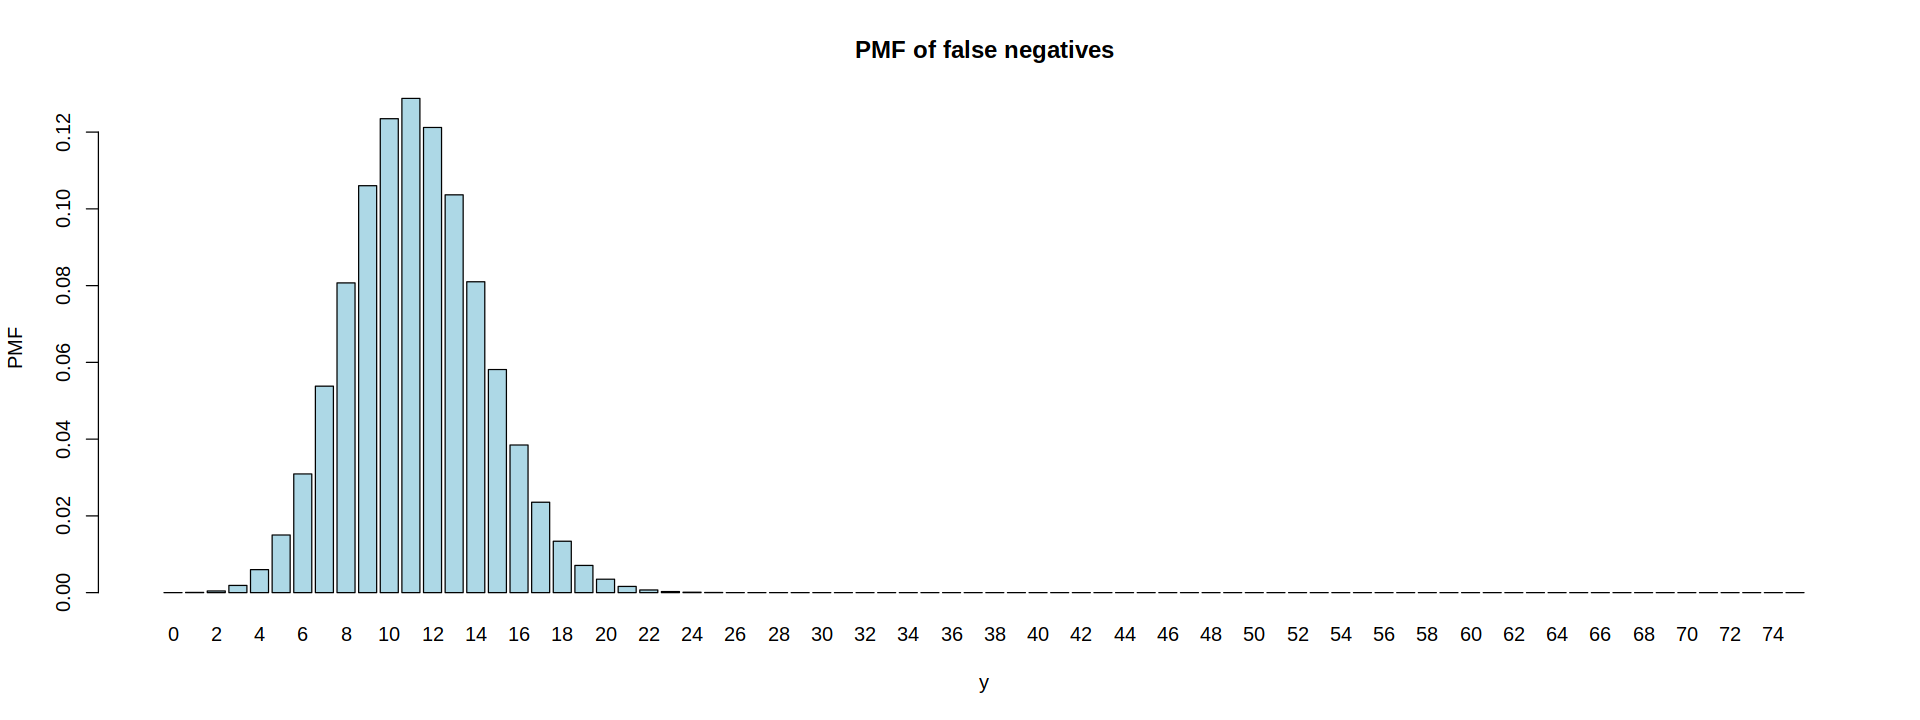

In [26]:
prob_fail <- 0.15
n <- 75
x_val <- 0:75

# PMF values:
y_val <- dbinom(x_val, n, prob_fail)

# PLOT:
options(repr.plot.width = 16, repr.plot.height = 6)
barplot(y_val, 
        names.arg=x_val,
        main = "PMF of false negatives",
        xlab = "y",
        ylab = "PMF",
        col='lightblue')

#### 2. Let n = 75 be the patient sample, the new method fails to detect the disease in y = 6 cases. What is the frequentist estimator for the failure probability of the new method ?

The prob is given simply by the ration $y/n$

In [27]:
y <- 6
prob <- y/n
err <- sqrt(prob*(1-prob)/n)
cat("Frequentist estimator for failure probability:", prob, "      with error:", err)

Frequentist estimator for failure probability: 0.08       with error: 0.03132624

#### 3. In Bayesian setting, evaluate the posterior probability, assuming a beta distribution with mean value 0.15 and standard deviation 0.14. Plot the posterior distribution for y, and mark on the plot the mean value and variance.

To determine the parameters $\alpha$ and $\beta$ of the Beta prior based on the given mean $\mu$ and standard deviation $\sigma$, we use the following formulas:

$$
\alpha = \mu \left( \frac{\mu(1 - \mu)}{\sigma^2} - 1 \right),
\quad \quad \quad
\beta = (1 - \mu) \left( \frac{\mu(1 - \mu)}{\sigma^2} - 1 \right)
$$

We can then use the beta-binomial model for the posterior.

prior parameters:        alpha  0.8257653   beta  4.679337 
posterior parameters:    alpha  6.825765    beta  73.67934 
mean:   0.08478674      variance:  0.0009520625

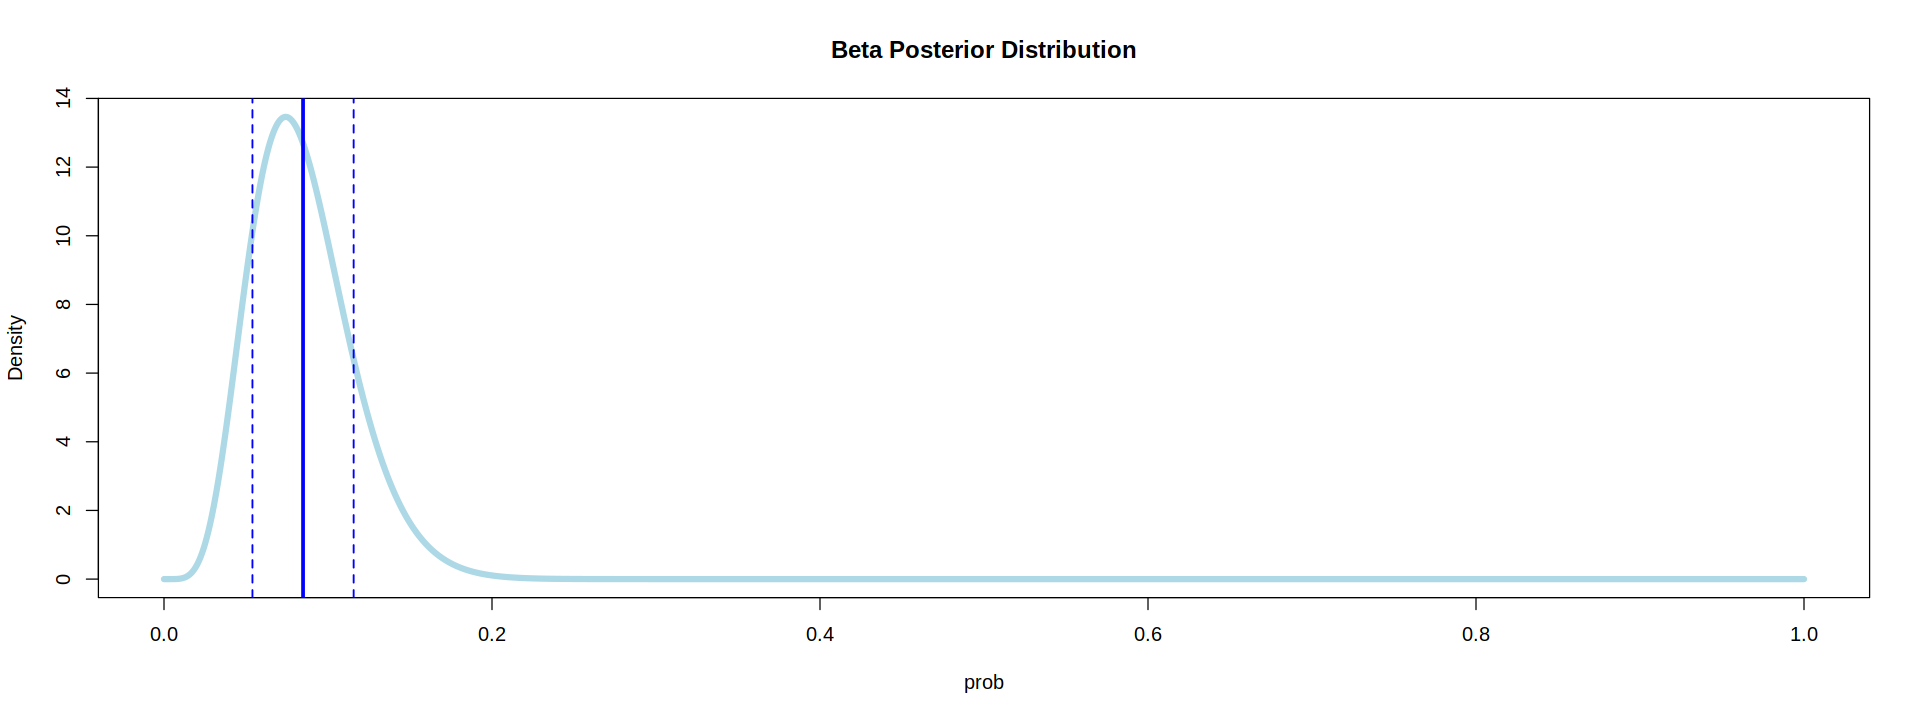

In [51]:
# parameters:
mu <- 0.15     # mean
std <- 0.14    # standard deviation
x_val <- seq(0, 1, 0.0001)

# prior distribution:
common <- mu * (1 - mu) / std^2 - 1          # common term in formula
alpha_pr <- mu * common
beta_pr <- (1 - mu) * common
prior <- dbeta(x_val, alpha_pr, beta_pr)
cat("prior parameters:        alpha ", alpha_pr, "  beta ", beta_pr, "\n")

# posterior distribution:
alpha_post <- alpha_prior + y                # = alpha + successes
beta_post  <- beta_prior + (n-y)             # = beta + failures
posterior  <- dbeta(x_val, alpha_post, beta_post)
mean_post  <- alpha_post / (alpha_post + beta_post)
var_post   <- var_beta <- (alpha_post * beta_post) / ((alpha_post + beta_post)^2 * (alpha_post + beta_post + 1))
cat("posterior parameters:    alpha ", alpha_post, "   beta ", beta_post, "\n")

# PLOT:
options(repr.plot.width = 16, repr.plot.height = 6)
plot(x_val, posterior, type = "l", lwd=5,
     main = "Beta Posterior Distribution",
     xlab = "prob", ylab = "Density", col="lightblue")
abline(v = mean_post, col = "blue", lwd=3)
abline(v = mean_post+sqrt(var_post), col = "blue", lwd=1.5, lty=2)
abline(v = mean_post-sqrt(var_post), col = "blue", lwd=1.5, lty=2)

# printing results:
cat("mean:  ", mean_post, "     variance: ", var_post)

#### 4. Perform a hypothesis test assuming that if the probability of failing to the detect the desease in ill patients is greater or equal than 15%, the new test is no better that the traditional method. Test the sample at a 5% level of significance in the Bayesian setting.

We're testing the hypothesis:
* Null ($H_0$): The new test is no better → false negative rate $θ≥0.15$
* Alternative ($H_1$): The new test is better → $θ<0.15$

We use Bayesian inference to calculate the posterior probability of $θ≥0.15$, and compare it to our threshold (significance level $α=0.05$).

In [60]:
prob <- 0.15
s_level <- 0.05
prob_less <- pbeta(prob, alpha_post, beta_post)
cat("Null hypothesis: posterior prob of θ≥0.15: ", 1 - prob_less, " < ", "0.05" , "\n")

Null hypothesis: posterior prob of θ≥0.15:  0.03127933  <  0.05 


So we reject null hypothesis.

#### 5. Perform the same hypothesis test in the classical frequentist setting.

In [63]:
x <- 6        # observed false negatives
n <- 75       # total ill patients tested
p0 <- 0.15    # threshold under H0

binom.test(x, n, p = p0, alternative = "less", conf.level=0.95)



	Exact binomial test

data:  x and n
number of successes = 6, number of trials = 75, p-value = 0.05435
alternative hypothesis: true probability of success is less than 0.15
95 percent confidence interval:
 0.0000000 0.1517971
sample estimates:
probability of success 
                  0.08 


In this case, we do not reject the null hypothesis. We are in a borderline case.

---